# Visualize Preprocessed DNS Snapshots (Static Plots)

This notebook loads a subsampled `.npz` file and provides tools to visualize the data across different spatial and temporal planes. Each cell generates a single, non-interactive plot. To change the plot, modify the parameters defined in the code cell.

It is divided into two main sections:
1.  **Spatial Slice Plots:** View a 2D spatial plane (`X-Y`, `X-Z`, or `Y-Z`) at a specific moment in time.
2.  **Time Evolution Plots:** View the evolution of a 1D spatial line over time (Time-X, Time-Y, or Time-Z plots).

### 1. Setup and Imports

In [1]:
import numpy as np
from pathlib import Path

# Import all necessary plotting functions from your core module
from mhd_surrogate_core.plot import (
    plot_xz_slice, 
    plot_xy_slice, 
    plot_yz_slice,
    plot_z_time_evolution,
    plot_x_time_evolution,
    plot_y_time_evolution
)

### 2. Load Data

**Action Required:** Change the `data_file_path` variable below to point to the specific `.npz` file you want to analyze.

In [2]:
# <<< CHANGE THIS PATH >>>
data_file_path = Path("/raid/skowronek/preprocessed_dns_output/01-Cold_Runs/01-Re16K_Ha325/T1220_x1151_y5_z127_c3/T1220_x1151_y5_z127_c3.npz")

# Load metadata to configure plot parameters
if not data_file_path.exists():
    print(f"ERROR: Data file not found at {data_file_path}. Please set the correct path.")
    # Assign dummy data if file not found to prevent errors
    channel_options = ['vx', 'vy', 'vz']
    max_time_index, max_x_index, max_y_index, max_z_index = 10, 10, 10, 10
else:
    with np.load(data_file_path, allow_pickle=True) as data:
        channel_options = list(data['labels'])
        # Assumes data shape is (time, x, y, z, channel)
        max_time_index = data['timeseries'].shape[0] - 1
        max_x_index = data['timeseries'].shape[1] - 1
        max_y_index = data['timeseries'].shape[2] - 1
        max_z_index = data['timeseries'].shape[3] - 1
    print("Data loaded successfully.")
    print(f"Available channels: {channel_options}")
    print(f"Max indices -> Time: {max_time_index}, X: {max_x_index}, Y: {max_y_index}, Z: {max_z_index}")

Data loaded successfully.
Available channels: ['vx', 'vy', 'vz']
Max indices -> Time: 1219, X: 1150, Y: 4, Z: 126


---

### 3. Spatial Slice Plots (2D)

#### 3.1 X-Z Slice (at constant Y)

Plotting X-Z slice for channel 'vx' at y_index=2, time_index=609


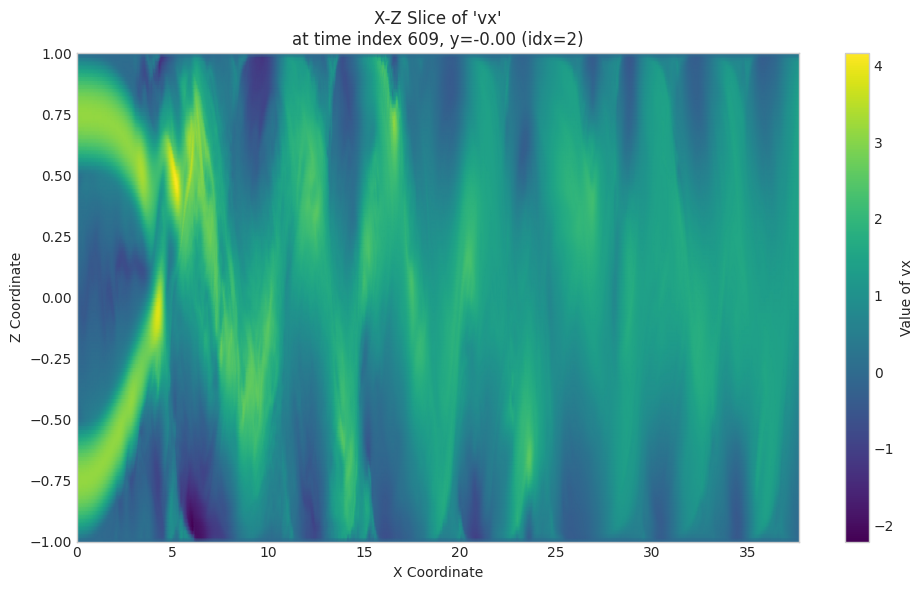

In [3]:
# --- Define parameters for the X-Z slice ---
# <<< MODIFY THESE VALUES >>>
plot_channel_xz = channel_options[0]  # e.g., 'vx'
plot_y_index_xz = max_y_index // 2
plot_time_index_xz = max_time_index // 2
# ---

print(f"Plotting X-Z slice for channel '{plot_channel_xz}' at y_index={plot_y_index_xz}, time_index={plot_time_index_xz}")
plot_xz_slice(
    data_path=data_file_path,
    channel=plot_channel_xz,
    y_index=plot_y_index_xz,
    time_index=plot_time_index_xz
)

#### 3.2 X-Y Slice (at constant Z)

Plotting X-Y slice for channel 'vx' at z_index=63, time_index=609


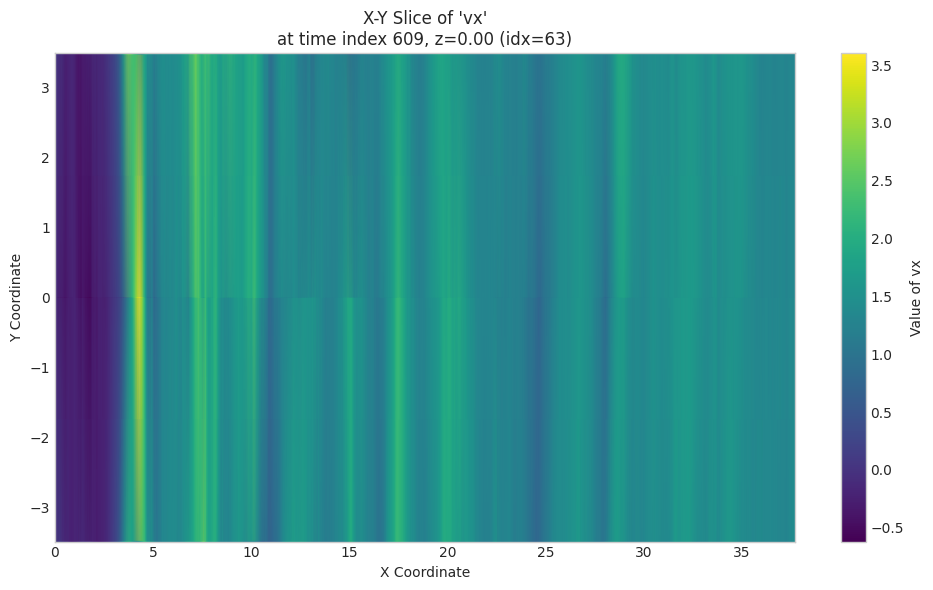

In [4]:
# --- Define parameters for the X-Y slice ---
# <<< MODIFY THESE VALUES >>>
plot_channel_xy = channel_options[0]
plot_z_index_xy = max_z_index // 2
plot_time_index_xy = max_time_index // 2
# ---

print(f"Plotting X-Y slice for channel '{plot_channel_xy}' at z_index={plot_z_index_xy}, time_index={plot_time_index_xy}")
plot_xy_slice(
    data_path=data_file_path,
    channel=plot_channel_xy,
    z_index=plot_z_index_xy,
    time_index=plot_time_index_xy
)

#### 3.3 Y-Z Slice (at constant X)

Plotting Y-Z slice for channel 'vx' at x_index=575, time_index=609


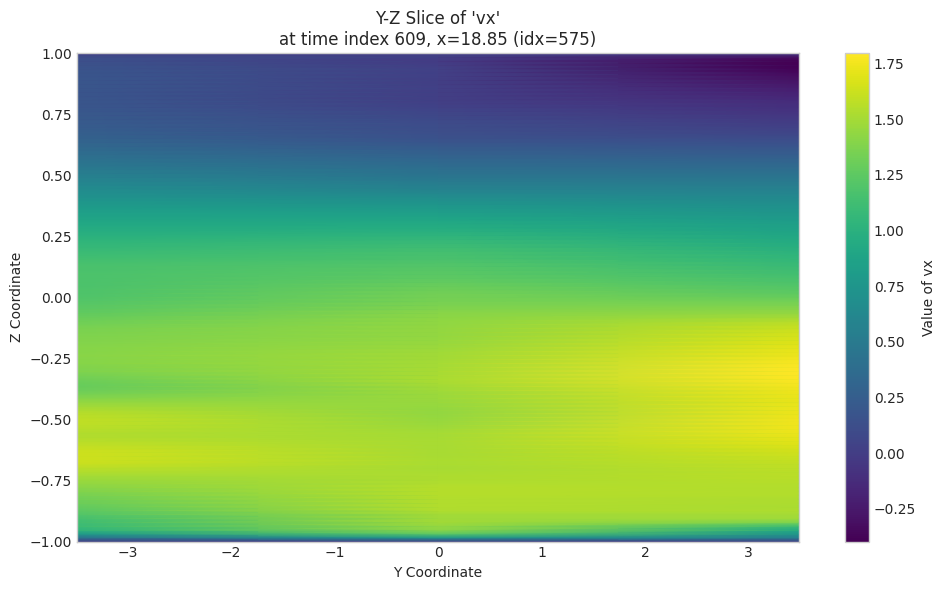

In [5]:
# --- Define parameters for the Y-Z slice ---
# <<< MODIFY THESE VALUES >>>
plot_channel_yz = channel_options[0]
plot_x_index_yz = max_x_index // 2
plot_time_index_yz = max_time_index // 2
# ---

print(f"Plotting Y-Z slice for channel '{plot_channel_yz}' at x_index={plot_x_index_yz}, time_index={plot_time_index_yz}")
plot_yz_slice(
    data_path=data_file_path,
    channel=plot_channel_yz,
    x_index=plot_x_index_yz,
    time_index=plot_time_index_yz
)

---

### 4. Time Evolution Plots (1D Line over Time)

#### 4.1 Evolution along Z-axis (at constant X, Y)

Plotting Time-Z evolution for channel 'vx' at x_index=575, y_index=2


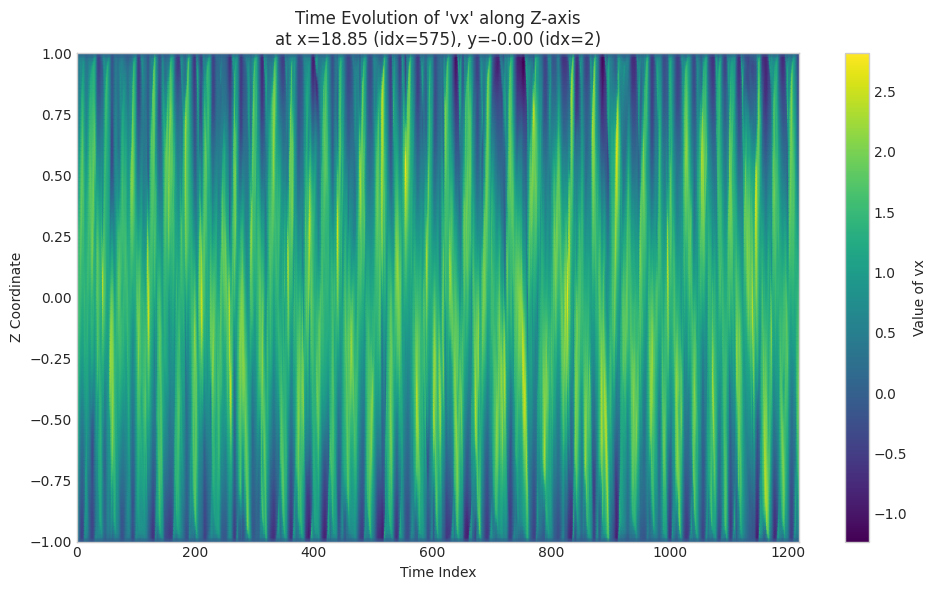

In [6]:
# --- Define parameters for the Time-Z plot ---
# <<< MODIFY THESE VALUES >>>
plot_channel_tz = channel_options[0]
plot_x_index_tz = max_x_index // 2
plot_y_index_tz = max_y_index // 2
# ---

print(f"Plotting Time-Z evolution for channel '{plot_channel_tz}' at x_index={plot_x_index_tz}, y_index={plot_y_index_tz}")
plot_z_time_evolution(
    data_path=data_file_path,
    channel=plot_channel_tz,
    x_index=plot_x_index_tz,
    y_index=plot_y_index_tz
)

#### 4.2 Evolution along X-axis (at constant Y, Z)

Plotting Time-X evolution for channel 'vx' at y_index=2, z_index=63


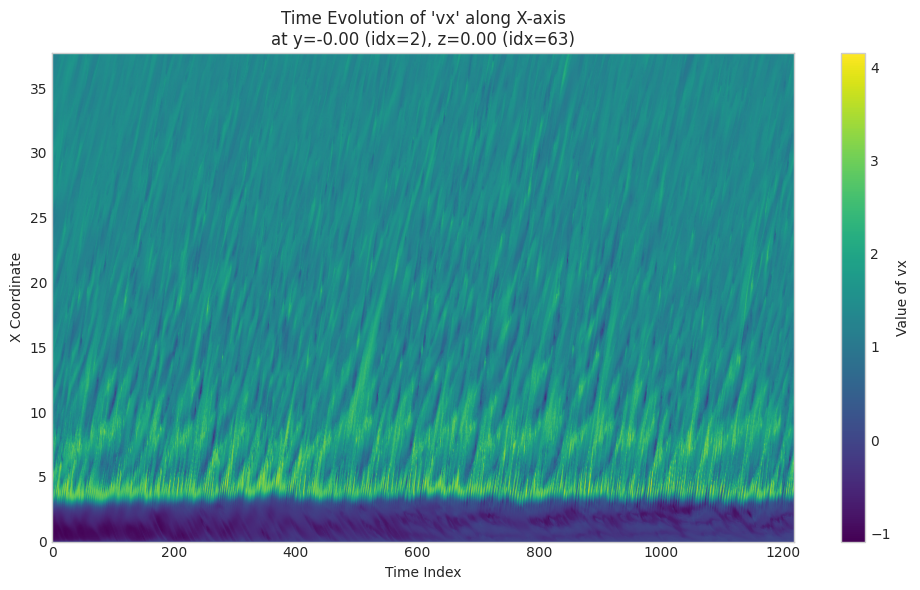

In [7]:
# --- Define parameters for the Time-X plot ---
# <<< MODIFY THESE VALUES >>>
plot_channel_tx = channel_options[0]
plot_y_index_tx = max_y_index // 2
plot_z_index_tx = max_z_index // 2
# ---

print(f"Plotting Time-X evolution for channel '{plot_channel_tx}' at y_index={plot_y_index_tx}, z_index={plot_z_index_tx}")
plot_x_time_evolution(
    data_path=data_file_path,
    channel=plot_channel_tx,
    y_index=plot_y_index_tx,
    z_index=plot_z_index_tx
)

#### 4.3 Evolution along Y-axis (at constant X, Z)

Plotting Time-Y evolution for channel 'vx' at x_index=575, z_index=63


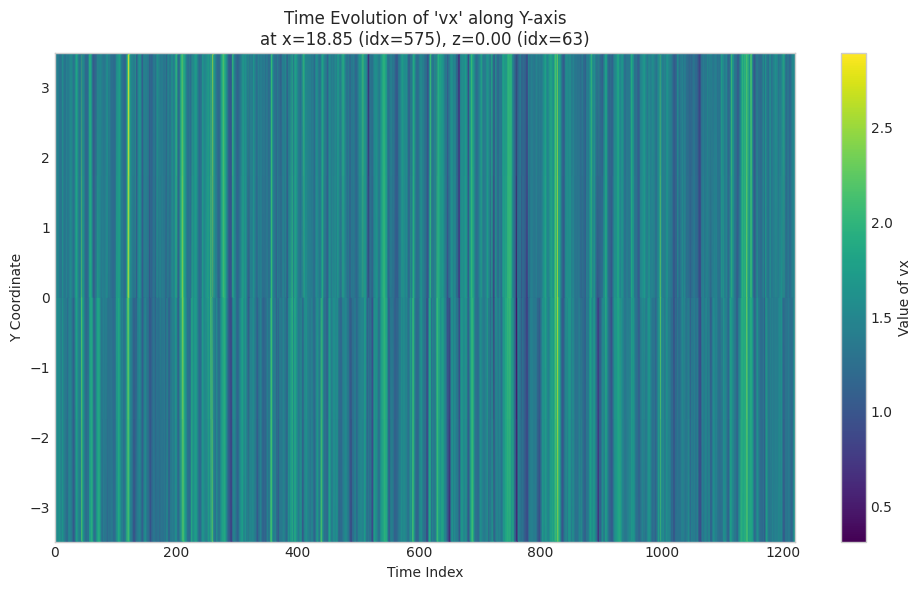

In [8]:
# --- Define parameters for the Time-Y plot ---
# <<< MODIFY THESE VALUES >>>
plot_channel_ty = channel_options[0]
plot_x_index_ty = max_x_index // 2
plot_z_index_ty = max_z_index // 2
# ---

print(f"Plotting Time-Y evolution for channel '{plot_channel_ty}' at x_index={plot_x_index_ty}, z_index={plot_z_index_ty}")
plot_y_time_evolution(
    data_path=data_file_path,
    channel=plot_channel_ty,
    x_index=plot_x_index_ty,
    z_index=plot_z_index_ty
)